In [ ]:
pip install lightgbm imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [ ]:
df = pd.read_csv("week2_AI4I2020.zip")

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,Process temperature [K]_RollingVar,Rotational speed [rpm]_RollingVar,Torque [Nm]_RollingVar,Tool wear [min]_RollingVar,Ambient Temperature,Factory Load,Temperature Difference,Torque_per_ToolWear,Speed_Torque,Ambient_Impact
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,...,0.007,3965.3,17.835,12.2,26.490142,1,10.5,42.800000,66382.8,8174.857963
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,...,0.007,3965.3,17.835,12.2,24.585207,0,10.5,11.575000,65190.4,7589.453431
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,...,0.007,3965.3,17.835,12.2,26.943066,0,10.4,8.233333,74001.2,8311.935742
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,...,0.007,3965.3,17.835,12.2,29.569090,0,10.4,4.937500,56603.5,9125.021041
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,...,0.007,3965.3,17.835,12.2,24.297540,1,10.5,4.000000,56320.0,7500.650560


In [ ]:
# Remove special characters from column names
df.columns = (
    df.columns
      .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
      .str.replace(r'_+', '_', regex=True)
      .str.strip('_')
)

print(df.columns)

Index(['Type', 'Air_temperature_K', 'Process_temperature_K',
       'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure',
       'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Air_temperature_K_RollingMean',
       'Process_temperature_K_RollingMean', 'Rotational_speed_rpm_RollingMean',
       'Torque_Nm_RollingMean', 'Tool_wear_min_RollingMean',
       'Air_temperature_K_RollingStd', 'Process_temperature_K_RollingStd',
       'Rotational_speed_rpm_RollingStd', 'Torque_Nm_RollingStd',
       'Tool_wear_min_RollingStd', 'Air_temperature_K_RollingVar',
       'Process_temperature_K_RollingVar', 'Rotational_speed_rpm_RollingVar',
       'Torque_Nm_RollingVar', 'Tool_wear_min_RollingVar',
       'Ambient_Temperature', 'Factory_Load', 'Temperature_Difference',
       'Torque_per_ToolWear', 'Speed_Torque', 'Ambient_Impact'],
      dtype='object')


In [ ]:
X = df.drop(columns=[
    "Machine_failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine_failure"]

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

In [ ]:
for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    smote = SMOTE(random_state=42)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    model = LGBMClassifier(
        random_state=42,
        learning_rate=0.05,
        n_estimators=200,
        num_leaves=31
    )

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))


========== Fold 1 ==========
[LightGBM] [Info] Number of positive: 7728, number of negative: 7728
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6373
[LightGBM] [Info] Number of data points in the train set: 15456, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy : 0.99
Precision: 0.9123
Recall   : 0.7761
F1 Score : 0.8387

========== Fold 2 ==========
[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031553 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6372
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 27
[LightGBM] 

In [ ]:
print("\n========== Average Performance ==========")

print("Average Accuracy :", np.mean(accuracy_list))

print("Average Precision :", np.mean(precision_list))

print("Average Recall :", np.mean(recall_list))

print("Average F1 Score :", np.mean(f1_list))


========== Average Performance ==========
Average Accuracy : 0.9882000000000002
Average Precision : 0.887390564276447
Average Recall : 0.7493415276558385
Average F1 Score : 0.8106634397966191


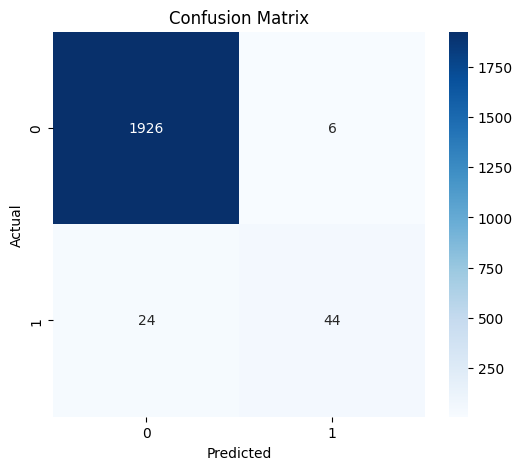

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.65      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000



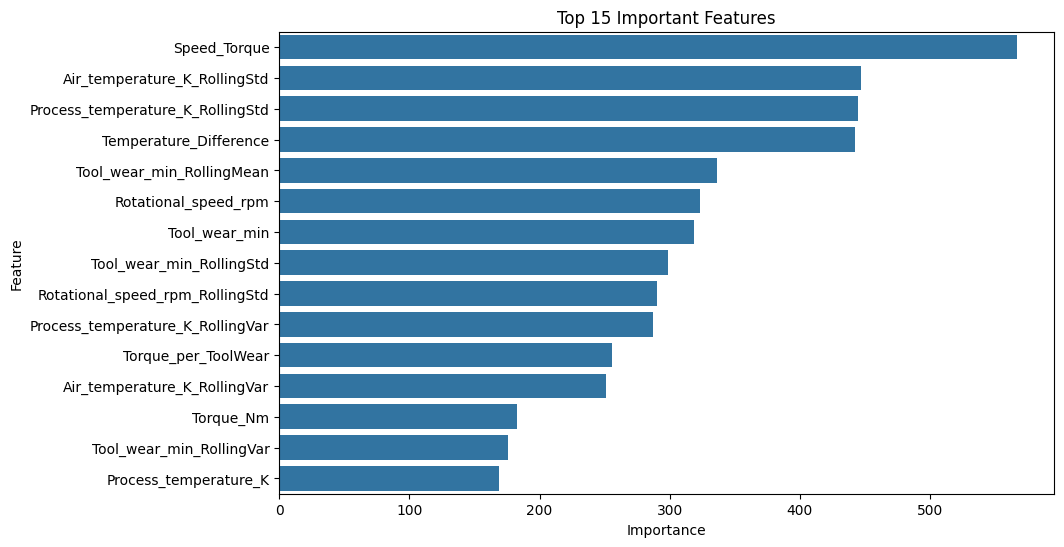

In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
joblib.dump(
    model,
    "predictive_maintenance_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
